# Extracting random samples from Xarray.DataArrays <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3), 

## Description
A _compulsory_ description of the notebook, including a brief overview of how Digital Earth Australia helps to address the problem set out above.
It can be good to include a run-down of the tools/methods that will be demonstrated in the notebook:

1. First we do this
2. Then we do this
3. Finally we do this

***

### Load packages

Import Python packages that are used for the analysis

In [2]:
import datacube
import numpy as np
import xarray as xr 
from odc.geo.xr import assign_crs
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, "../Tools/")
from dea_tools.validation import random_sampling

### Connect to the datacube

Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='random_sampling')

### Analysis parameters

An *optional* section to inform the user of any parameters they'll need to configure to run the notebook:

* `param_name_1`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.
* `param_name_2`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.


In [4]:
# Set the central latitude and longitude
central_lat = -35.29
central_lon =  149.113

# Set the buffer to load around the central coordinates. 
buffer = 0.2

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

start_date = "2023-01-01"
end_date = "2023-12-31"

In [5]:
# Lazy load our filtered data
ds = dc.load(
    product="ga_ls8cls9c_gm_cyear_3",
    x=longitude,
    y=latitude,
    time=(start_date, end_date),
    measurements=["nbart_red", 'nbart_green', 'nbart_blue'],
    output_crs="EPSG:3577",
    resolution=(30, -30),
)

ds = ds.squeeze()

In [6]:
urban_GUF = xr.open_dataarray('https://thredds.nci.org.au/thredds/dodsC/ub8/au/LandCover/OzWALD_LC/GUF_FractionUrban_Australia.nc')
urban_GUF = urban_GUF.transpose('latitude', 'longitude')
urban_GUF = assign_crs(urban_GUF, crs='EPSG:4326')

urban_GUF = urban_GUF.odc.reproject(how=ds.odc.geobox, resampling='bilinear')
urban = xr.where(urban_GUF>75, 1, urban_GUF)
urban = xr.where((urban <=75) & (urban >1), 2, urban)
urban = assign_crs(urban.astype('int16'), crs='EPSG:3577')

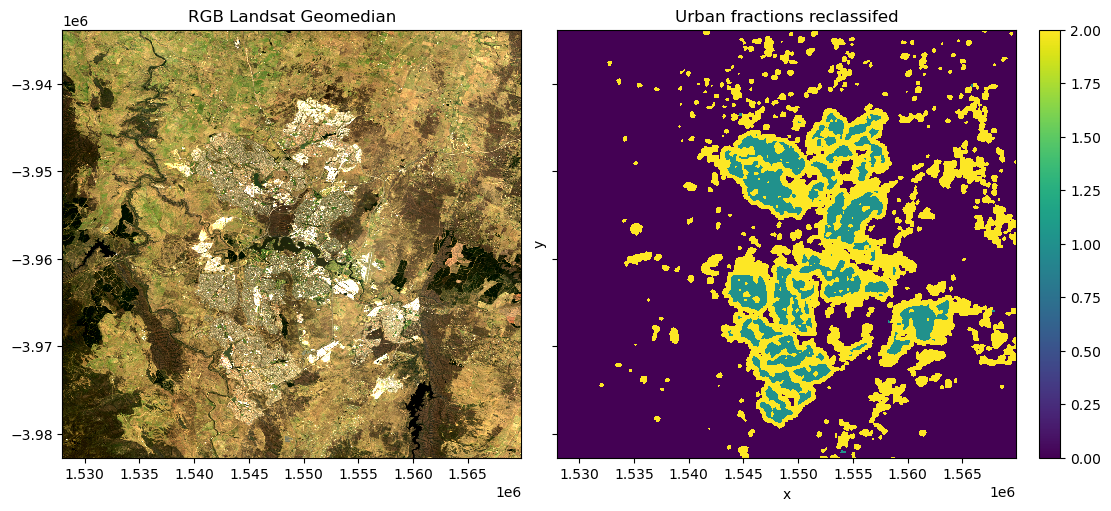

In [7]:
fig, ax = plt.subplots(1,2, figsize=(11,5), sharey=True, layout='constrained')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
ax[0].set_title("RGB Landsat Geomedian");

urban.plot(ax=ax[1])
ax[1].set_title("Urban fractions reclassifed");

## Extract random samples using different sampling strategies

In [8]:
train_points_manual = random_sampling(urban, sampling='manual', manual_class_ratios={'1':100, '0':300})

train_points_stratified_random = random_sampling(urban, sampling='stratified_random', n=400)

train_points_equal_stratified_random = random_sampling(urban, sampling='equal_stratified_random', n=400)

train_points_random = random_sampling(urban, sampling='random', n=400)

Class 0: sampled at 300 coordinates
Class 1: sampled at 100 coordinates
Class 0: sampling at 297 coordinates
Class 2: sampling at 75 coordinates
Class 1: sampling at 28 coordinates
Class 0: sampling at 133 coordinates
Class 1: sampling at 133 coordinates
Class 2: sampling at 133 coordinates
Randomly sampling dataAraay at 400 coordinates


## Plot

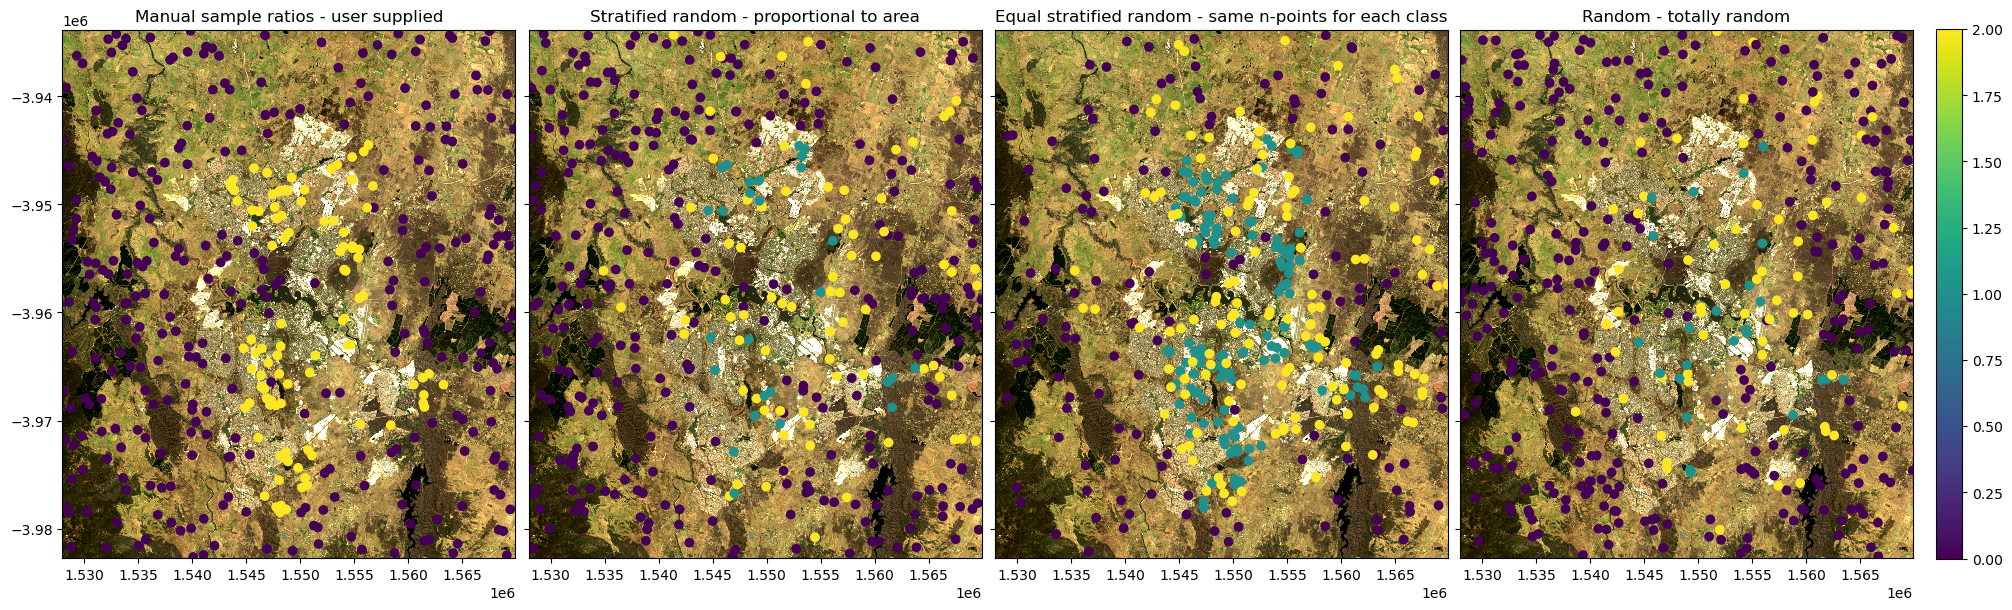

In [9]:
fig, ax = plt.subplots(1,4, figsize=(20,6), sharey=True, layout='constrained')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
train_points_manual.plot(ax=ax[0], column='class')
ax[0].set_title('Manual sample ratios - user supplied')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[1], add_labels=False)
train_points_stratified_random.plot(ax=ax[1], column='class')
ax[1].set_title('Stratified random - proportional to area')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[2], add_labels=False)
train_points_equal_stratified_random.plot(ax=ax[2], column='class')
ax[2].set_title('Equal stratified random - same n-points for each class')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[3], add_labels=False)
train_points_random.plot(ax=ax[3], column='class', legend=True)
ax[3].set_title('Random - totally random');


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2025

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->